# PSF 可视化与验证

本 notebook 用于可视化和验证 PSF (Point Spread Function) 文件：
- 加载 PSF 文件
- 可视化 2D/3D 分布
- 检查 PSF 质量（归一化、对称性、中心位置）
- 对比真实 PSF 与高斯 PSF

## 1. 导入依赖

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from PIL import Image
from pathlib import Path
import os

print("依赖加载完成")

依赖加载完成


## 2. 工具函数

In [26]:
def load_image(path):
    """加载图像为 float32 数组"""
    arr = np.array(Image.open(path)).astype(np.float32)
    return arr.mean(axis=2) if arr.ndim == 3 else arr

def percentile_norm(x, pmin=0.1, pmax=99.9, eps=1e-8):
    """百分位归一化"""
    lo = np.percentile(x, pmin)
    hi = np.percentile(x, pmax)
    return np.clip((x - lo) / max(hi - lo, eps), 0.0, 1.0)

def gaussian_psf(size=25, sigma=2.0):
    """生成高斯 PSF"""
    if size % 2 == 0:
        size += 1
    r = size // 2
    y, x = np.mgrid[-r:r + 1, -r:r + 1]
    psf = np.exp(-(x ** 2 / (2 * sigma ** 2) + y ** 2 / (2 * sigma ** 2)))
    psf = psf.astype(np.float32)
    psf /= np.maximum(psf.sum(), 1e-8)  # ✓ 正确归一化
    return psf

def load_psf_from_file(psf_path, size=25):
    """从文件加载真实 PSF，裁剪中心区域"""
    psf = load_image(psf_path)
    # psf = percentile_norm(psf)  # ❌ 不要用！会截断 PSF
    
    h, w = psf.shape
    center_y, center_x = h // 2, w // 2
    half = size // 2
    
    top = max(0, center_y - half)
    bottom = min(h, center_y + half + 1)
    left = max(0, center_x - half)
    right = min(w, center_x + half + 1)
    
    psf = psf[top:bottom, left:right]
    
    if psf.shape[0] < size or psf.shape[1] < size:
        pad_h = size - psf.shape[0]
        pad_w = size - psf.shape[1]
        psf = np.pad(psf, ((0, pad_h), (0, pad_w)), mode='constant')
    
    psf /= np.maximum(psf.sum(), 1e-8)  # ✓ 正确归一化
    return psf

def check_psf_quality(psf):
    """检查 PSF 质量"""
    print("=" * 50)
    print("PSF 质量检查")
    print("=" * 50)
    print(f"形状：{psf.shape}")
    print(f"总和：{psf.sum():.6f} (应该≈1.0)")
    print(f"最大值：{psf.max():.6f}")
    print(f"最大值位置：{np.unravel_index(np.argmax(psf), psf.shape)}")
    print(f"最小值：{psf.min():.6f}")
    print(f"均值：{psf.mean():.6f}")
    print(f"标准差：{psf.std():.6f}")
    
    # 检查对称性
    center_y, center_x = psf.shape[0] // 2, psf.shape[1] // 2
    
    # 左右对称性
    left = psf[:, :center_x]
    right = psf[:, -center_x:][:, ::-1]
    sym_lr = np.corrcoef(left.flatten(), right.flatten())[0, 1]
    
    # 上下对称性
    top = psf[:center_y, :]
    bottom = psf[-center_y:, :][::-1, :]
    sym_ud = np.corrcoef(top.flatten(), bottom.flatten())[0, 1]
    
    print(f"\n对称性检查:")
    print(f"左右对称相关系数：{sym_lr:.4f} (越接近 1 越好)")
    print(f"上下对称相关系数：{sym_ud:.4f} (越接近 1 越好)")
    
    # 检查能量集中度
    sorted_vals = np.sort(psf.flatten())[::-1]
    cumsum = np.cumsum(sorted_vals)
    energy_50 = np.where(cumsum >= 0.5)[0][0] + 1
    energy_90 = np.where(cumsum >= 0.9)[0][0] + 1
    print(f"\n能量集中度:")
    print(f"50% 能量像素数：{energy_50}")
    print(f"90% 能量像素数：{energy_90}")
    
    quality_score = (sym_lr + sym_ud) / 2 * 100
    print(f"\n{'✓' if psf.sum() > 0.99 and psf.sum() < 1.01 else '✗'} PSF 已正确归一化")
    print(f"{'✓' if sym_lr > 0.9 and sym_ud > 0.9 else '⚠'} 对称性：{'好' if quality_score > 90 else '一般'}")
    print("=" * 50)
    
    return {
        'sum': psf.sum(),
        'sym_lr': sym_lr,
        'sym_ud': sym_ud,
        'quality_score': quality_score
    }

## 3. 配置 PSF 路径

In [27]:
# PSF 文件路径
PSF_PATH = "datasets/Microtubule/PSF/psf_emLambda525_dxy0.0313_NA1.3.tif"

# 裁剪尺寸
PSF_SIZE = 25

# 高斯 PSF 参数（用于对比）
GAUSSIAN_SIGMA = 2.75

print(f"PSF 路径：{PSF_PATH}")
print(f"PSF 尺寸：{PSF_SIZE}x{PSF_SIZE}")
print(f"高斯σ: {GAUSSIAN_SIGMA}")

# 检查文件是否存在
if not os.path.exists(PSF_PATH):
    print(f"\n⚠ 警告：PSF 文件不存在：{PSF_PATH}")
    print("请确认路径是否正确")
else:
    print(f"\n✓ PSF 文件存在")

PSF 路径：datasets/Microtubule/PSF/psf_emLambda525_dxy0.0313_NA1.3.tif
PSF 尺寸：25x25
高斯σ: 2.75

✓ PSF 文件存在


## 4. 加载 PSF

In [28]:
# 加载真实 PSF
print("加载真实 PSF...")
psf_real = load_psf_from_file(PSF_PATH, PSF_SIZE)

# 生成高斯 PSF（用于对比）
print(f"生成高斯 PSF (σ={GAUSSIAN_SIGMA})...")
psf_gaussian = gaussian_psf(PSF_SIZE, GAUSSIAN_SIGMA)

print(f"\n真实 PSF 形状：{psf_real.shape}")
print(f"高斯 PSF 形状：{psf_gaussian.shape}")

加载真实 PSF...
生成高斯 PSF (σ=2.75)...

真实 PSF 形状：(25, 25)
高斯 PSF 形状：(25, 25)


## 5. PSF 质量检查

In [29]:
# 检查真实 PSF 质量
print("\n=== 真实 PSF 质量检查 ===")
quality_real = check_psf_quality(psf_real)

# 检查高斯 PSF 质量
print("\n=== 高斯 PSF 质量检查 ===")
quality_gaussian = check_psf_quality(psf_gaussian)


=== 真实 PSF 质量检查 ===
PSF 质量检查
形状：(25, 25)
总和：1.000000 (应该≈1.0)
最大值：0.021209
最大值位置：(12, 12)
最小值：0.000000
均值：0.001600
标准差：0.003796

对称性检查:
左右对称相关系数：1.0000 (越接近 1 越好)
上下对称相关系数：1.0000 (越接近 1 越好)

能量集中度:
50% 能量像素数：33
90% 能量像素数：109

✓ PSF 已正确归一化
✓ 对称性：好

=== 高斯 PSF 质量检查 ===
PSF 质量检查
形状：(25, 25)
总和：1.000000 (应该≈1.0)
最大值：0.021045
最大值位置：(12, 12)
最小值：0.000000
均值：0.001600
标准差：0.003778

对称性检查:
左右对称相关系数：1.0000 (越接近 1 越好)
上下对称相关系数：1.0000 (越接近 1 越好)

能量集中度:
50% 能量像素数：34
90% 能量像素数：110

✓ PSF 已正确归一化
✓ 对称性：好


## 6. 2D 可视化

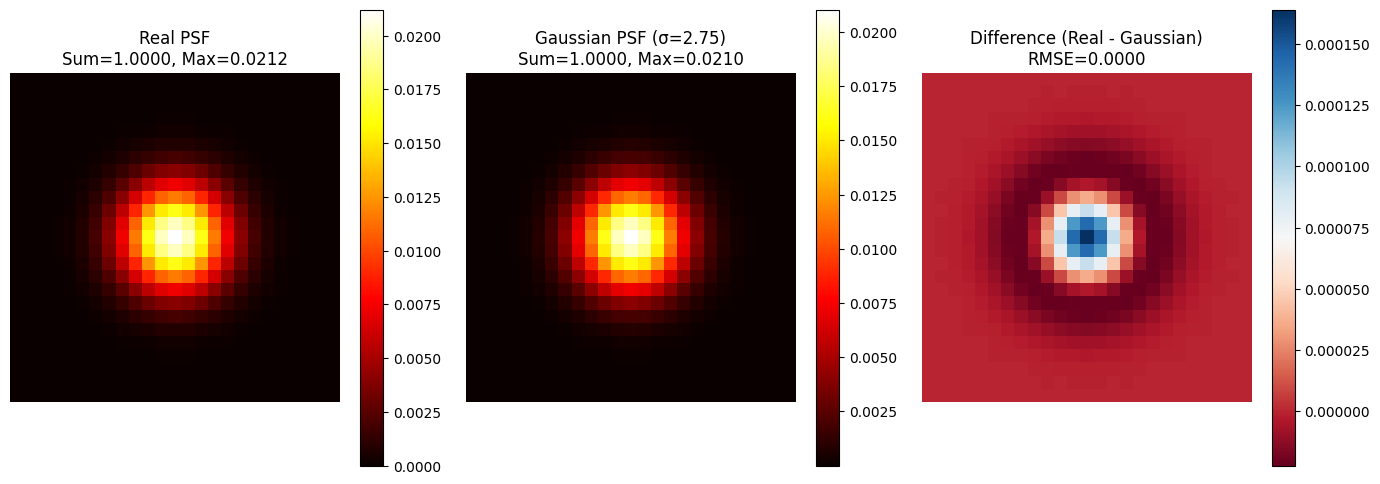

In [30]:
plt.figure(figsize=(14, 6))

# 真实 PSF
plt.subplot(1, 3, 1)
im1 = plt.imshow(psf_real, cmap='hot', interpolation='none')
plt.colorbar(im1, shrink=0.8)
plt.title(f"Real PSF\nSum={psf_real.sum():.4f}, Max={psf_real.max():.4f}")
plt.axis('off')

# 高斯 PSF
plt.subplot(1, 3, 2)
im2 = plt.imshow(psf_gaussian, cmap='hot', interpolation='none')
plt.colorbar(im2, shrink=0.8)
plt.title(f"Gaussian PSF (σ={GAUSSIAN_SIGMA})\nSum={psf_gaussian.sum():.4f}, Max={psf_gaussian.max():.4f}")
plt.axis('off')

# 差异图
diff = psf_real - psf_gaussian
plt.subplot(1, 3, 3)
im3 = plt.imshow(diff, cmap='RdBu', interpolation='none')
plt.colorbar(im3, shrink=0.8)
plt.title(f"Difference (Real - Gaussian)\nRMSE={np.sqrt(np.mean(diff**2)):.4f}")
plt.axis('off')

plt.tight_layout()
os.makedirs("output", exist_ok=True)
plt.savefig("output/psf_2d_comparison.png", dpi=150, bbox_inches='tight')
plt.show()

## 7. 3D 表面图

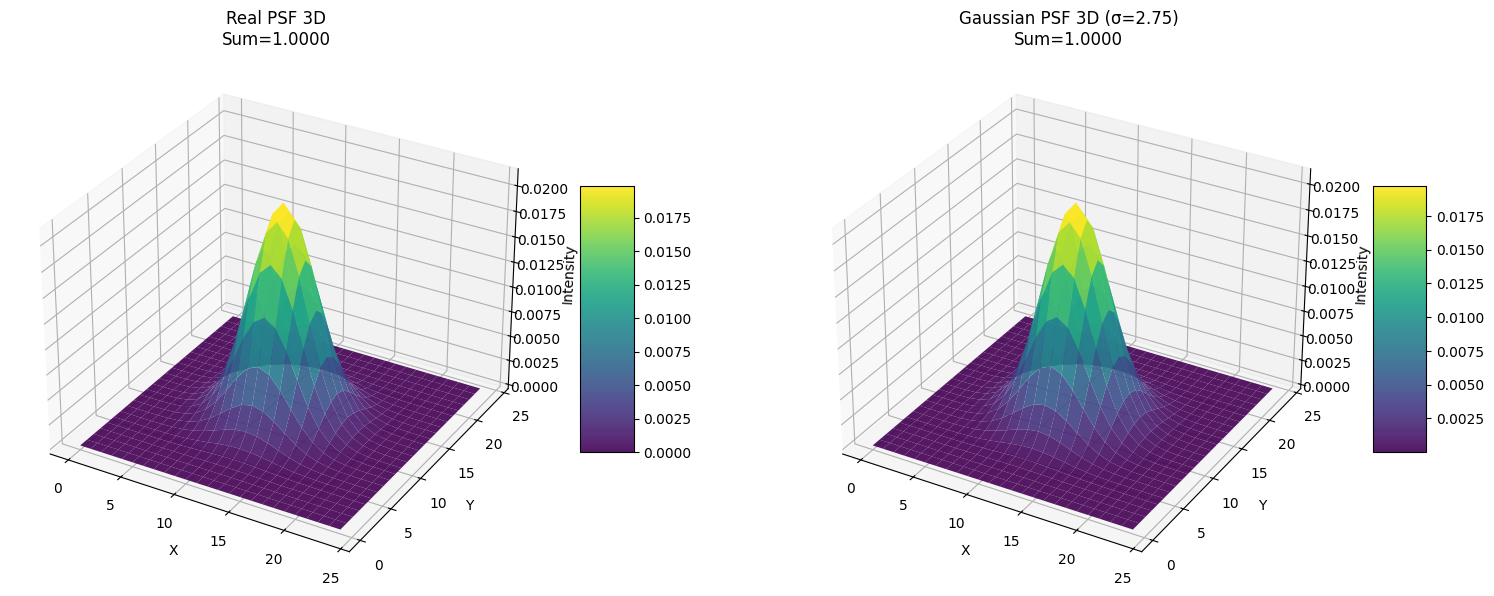

In [31]:
from matplotlib import cm
from matplotlib.ticker import LinearLocator

fig = plt.figure(figsize=(16, 6))

# 真实 PSF 3D
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
X, Y = np.meshgrid(np.arange(PSF_SIZE), np.arange(PSF_SIZE))
surf1 = ax1.plot_surface(X, Y, psf_real, cmap=cm.viridis,
                         linewidth=0, antialiased=True, alpha=0.9)
ax1.set_title(f"Real PSF 3D\nSum={psf_real.sum():.4f}")
ax1.set_xlabel('X')
ax1.set_ylabel('Y')
ax1.set_zlabel('Intensity')
fig.colorbar(surf1, ax=ax1, shrink=0.5, aspect=5)

# 高斯 PSF 3D
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
surf2 = ax2.plot_surface(X, Y, psf_gaussian, cmap=cm.viridis,
                         linewidth=0, antialiased=True, alpha=0.9)
ax2.set_title(f"Gaussian PSF 3D (σ={GAUSSIAN_SIGMA})\nSum={psf_gaussian.sum():.4f}")
ax2.set_xlabel('X')
ax2.set_ylabel('Y')
ax2.set_zlabel('Intensity')
fig.colorbar(surf2, ax=ax2, shrink=0.5, aspect=5)

plt.tight_layout()
plt.savefig("output/psf_3d_comparison.png", dpi=150, bbox_inches='tight')
plt.show()

## 8. 剖面线分析

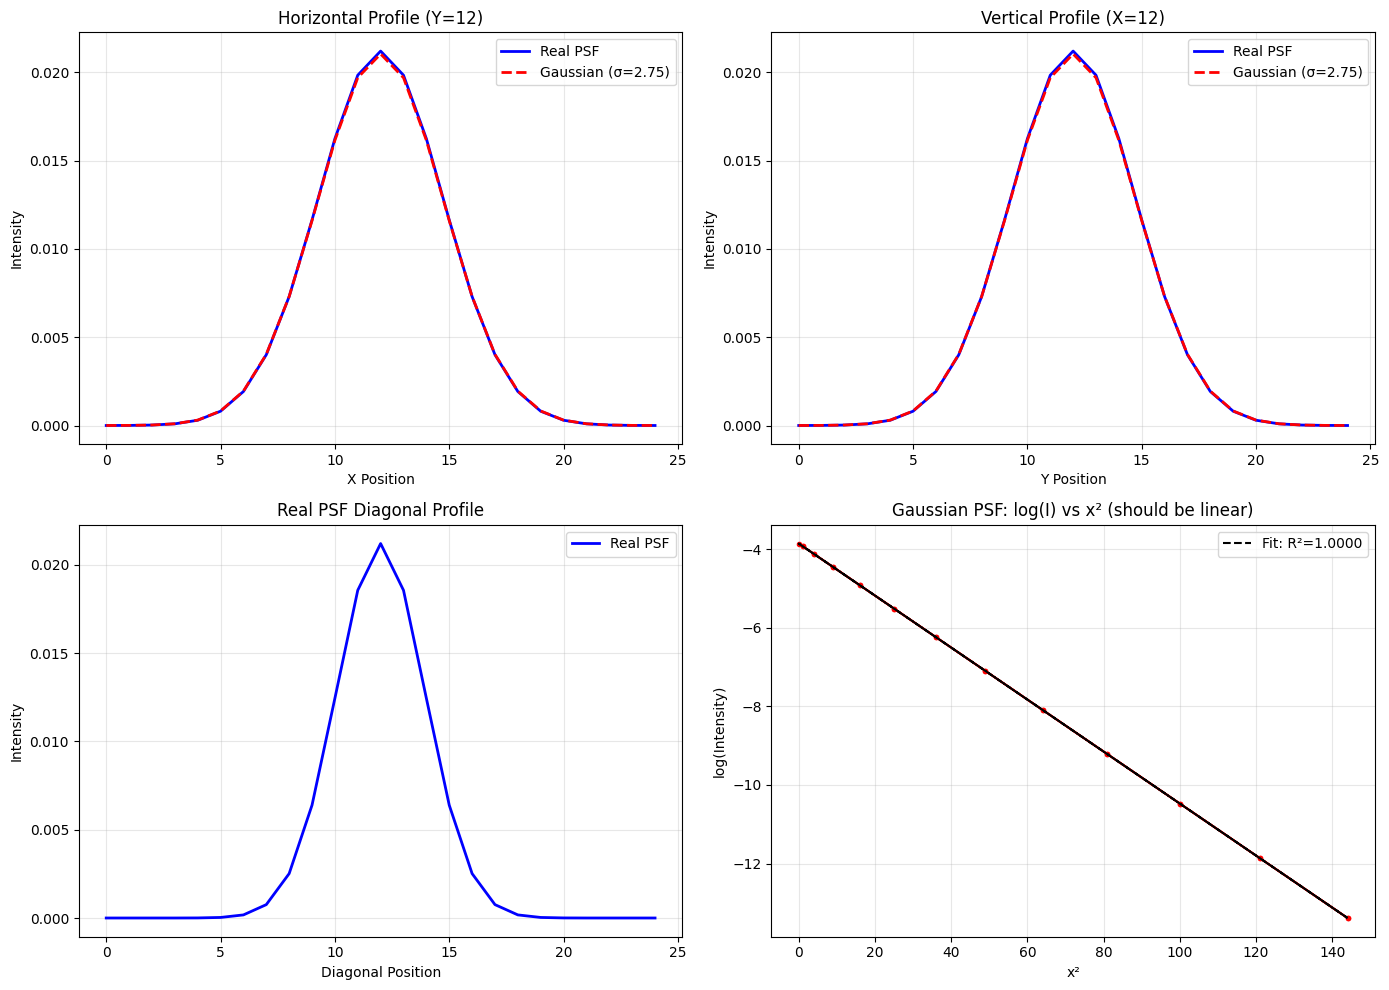


高斯拟合结果:
斜率：-0.066116
R²: 1.0000 (越接近 1 越符合高斯分布)
估计的σ: 2.75


In [32]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

center = PSF_SIZE // 2

# 水平剖面线
ax = axes[0, 0]
ax.plot(psf_real[center, :], 'b-', linewidth=2, label='Real PSF')
ax.plot(psf_gaussian[center, :], 'r--', linewidth=2, label=f'Gaussian (σ={GAUSSIAN_SIGMA})')
ax.set_xlabel('X Position')
ax.set_ylabel('Intensity')
ax.set_title(f'Horizontal Profile (Y={center})')
ax.legend()
ax.grid(True, alpha=0.3)

# 垂直剖面线
ax = axes[0, 1]
ax.plot(psf_real[:, center], 'b-', linewidth=2, label='Real PSF')
ax.plot(psf_gaussian[:, center], 'r--', linewidth=2, label=f'Gaussian (σ={GAUSSIAN_SIGMA})')
ax.set_xlabel('Y Position')
ax.set_ylabel('Intensity')
ax.set_title(f'Vertical Profile (X={center})')
ax.legend()
ax.grid(True, alpha=0.3)

# 真实 PSF 对角线剖面
ax = axes[1, 0]
diag_real = np.diag(psf_real)
ax.plot(diag_real, 'b-', linewidth=2, label='Real PSF')
ax.set_xlabel('Diagonal Position')
ax.set_ylabel('Intensity')
ax.set_title('Real PSF Diagonal Profile')
ax.legend()
ax.grid(True, alpha=0.3)

# 高斯 PSF 对数剖面（检查高斯特性）
ax = axes[1, 1]
center_line = psf_gaussian[center, :]
log_intensities = np.log(center_line + 1e-10)
x_vals = np.arange(PSF_SIZE) - center
ax.plot(x_vals**2, log_intensities, 'ro-', markersize=3)
ax.set_xlabel('x²')
ax.set_ylabel('log(Intensity)')
ax.set_title('Gaussian PSF: log(I) vs x² (should be linear)')
ax.grid(True, alpha=0.3)

# 线性拟合
from scipy import stats
valid_idx = log_intensities > -10  # 忽略太小的值
slope, intercept, r_value, p_value, std_err = stats.linregress(
    x_vals[valid_idx]**2, log_intensities[valid_idx]
)
ax.plot(x_vals**2, slope * x_vals**2 + intercept, 'k--', 
        label=f'Fit: R²={r_value**2:.4f}')
ax.legend()

plt.tight_layout()
plt.savefig("output/psf_profiles.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"\n高斯拟合结果:")
print(f"斜率：{slope:.6f}")
print(f"R²: {r_value**2:.4f} (越接近 1 越符合高斯分布)")
estimated_sigma = np.sqrt(-1 / (2 * slope))
print(f"估计的σ: {estimated_sigma:.2f}")

## 9. 频域分析 (OTF)

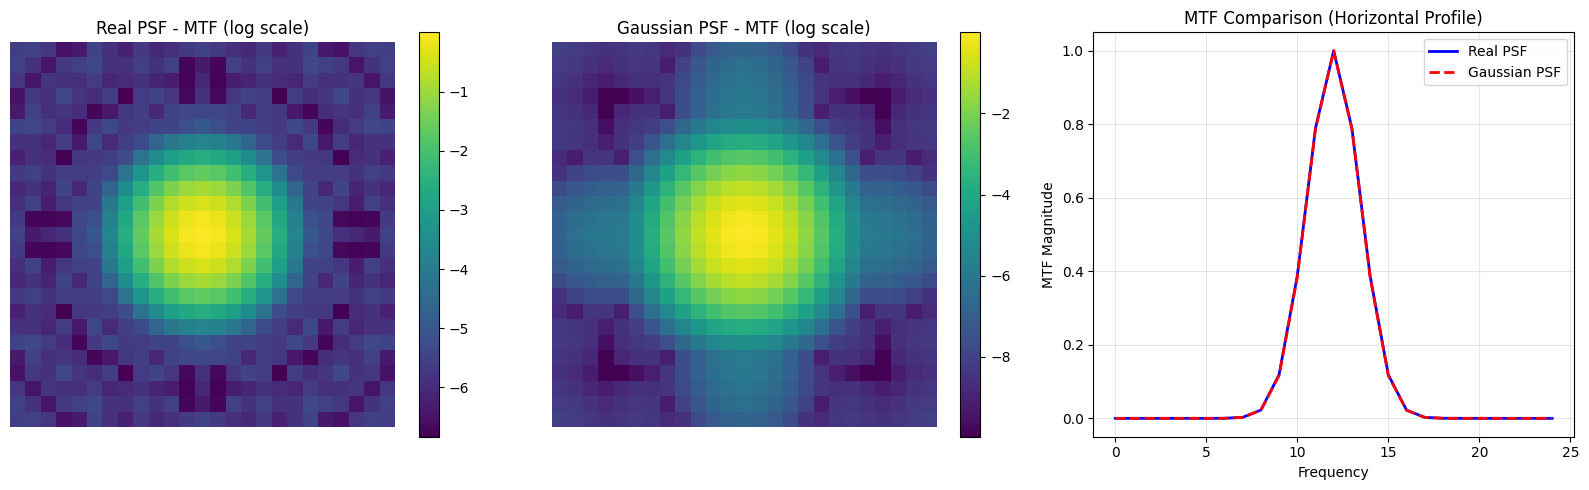


MTF 分析:
真实 PSF 的 MTF 最大值：1.0000
高斯 PSF 的 MTF 最大值：1.0000


In [33]:
# 计算光学传递函数 (OTF = PSF 的傅里叶变换)
otf_real = np.fft.fftshift(np.fft.fft2(psf_real))
otf_gaussian = np.fft.fftshift(np.fft.fft2(psf_gaussian))

mtf_real = np.abs(otf_real)  # 调制传递函数
mtf_gaussian = np.abs(otf_gaussian)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 真实 PSF 的 MTF
ax = axes[0]
im1 = ax.imshow(np.log10(mtf_real + 1e-10), cmap='viridis')
plt.colorbar(im1, ax=ax)
ax.set_title(f'Real PSF - MTF (log scale)')
ax.axis('off')

# 高斯 PSF 的 MTF
ax = axes[1]
im2 = ax.imshow(np.log10(mtf_gaussian + 1e-10), cmap='viridis')
plt.colorbar(im2, ax=ax)
ax.set_title(f'Gaussian PSF - MTF (log scale)')
ax.axis('off')

# MTF 对比（中心剖面）
ax = axes[2]
center = PSF_SIZE // 2
ax.plot(mtf_real[center, :], 'b-', linewidth=2, label='Real PSF')
ax.plot(mtf_gaussian[center, :], 'r--', linewidth=2, label='Gaussian PSF')
ax.set_xlabel('Frequency')
ax.set_ylabel('MTF Magnitude')
ax.set_title('MTF Comparison (Horizontal Profile)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("output/psf_otf_analysis.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"\nMTF 分析:")
print(f"真实 PSF 的 MTF 最大值：{mtf_real.max():.4f}")
print(f"高斯 PSF 的 MTF 最大值：{mtf_gaussian.max():.4f}")

## 10. PSF 在反卷积中的效果演示

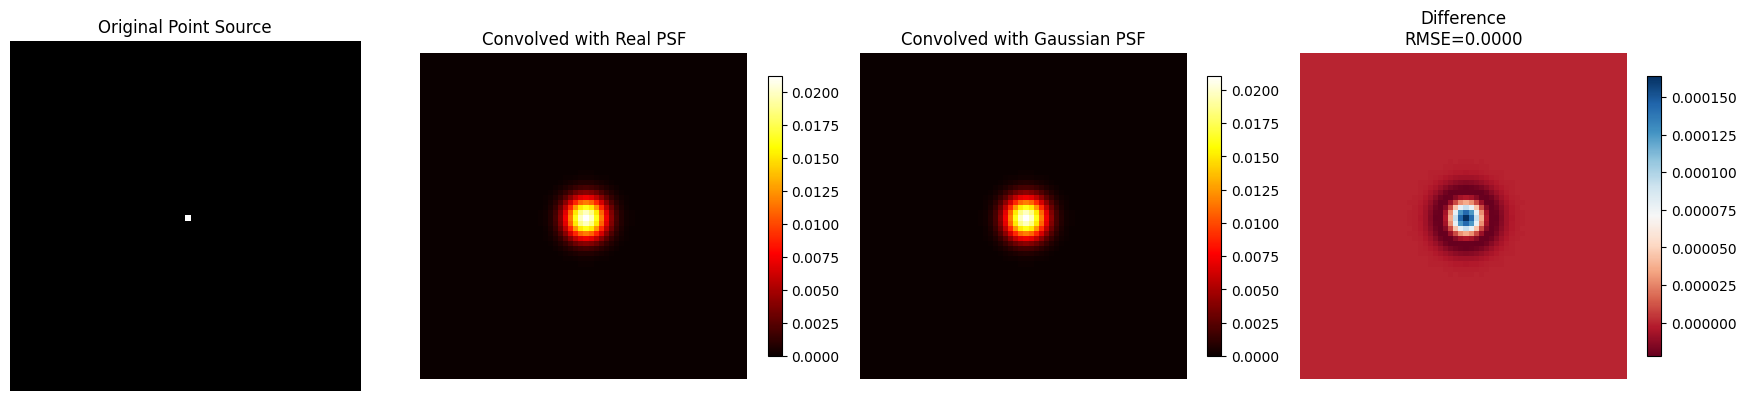


点源扩散分析:
真实 PSF 卷积后 FWHM: 37.0 像素
高斯 PSF 卷积后 FWHM: 37.0 像素


In [34]:
# 创建一个简单的测试图像（点源）
test_img = np.zeros((64, 64))
test_img[32, 32] = 1.0  # 中心点

# 用 PSF 卷积
from scipy import signal

convolved_real = signal.convolve2d(test_img, psf_real, mode='same')
convolved_gaussian = signal.convolve2d(test_img, psf_gaussian, mode='same')

fig, axes = plt.subplots(1, 4, figsize=(18, 4))

# 原始点源
ax = axes[0]
ax.imshow(test_img, cmap='gray')
ax.set_title('Original Point Source')
ax.axis('off')

# 真实 PSF 卷积
ax = axes[1]
im1 = ax.imshow(convolved_real, cmap='hot')
plt.colorbar(im1, ax=ax, shrink=0.8)
ax.set_title(f'Convolved with Real PSF')
ax.axis('off')

# 高斯 PSF 卷积
ax = axes[2]
im2 = ax.imshow(convolved_gaussian, cmap='hot')
plt.colorbar(im2, ax=ax, shrink=0.8)
ax.set_title(f'Convolved with Gaussian PSF')
ax.axis('off')

# 差异
ax = axes[3]
diff_conv = convolved_real - convolved_gaussian
im3 = ax.imshow(diff_conv, cmap='RdBu')
plt.colorbar(im3, ax=ax, shrink=0.8)
ax.set_title(f'Difference\nRMSE={np.sqrt(np.mean(diff_conv**2)):.4f}')
ax.axis('off')

plt.tight_layout()
plt.savefig("output/psf_convolution_demo.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"\n点源扩散分析:")
print(f"真实 PSF 卷积后 FWHM: {np.sum(convolved_real > convolved_real.max()/2):.1f} 像素")
print(f"高斯 PSF 卷积后 FWHM: {np.sum(convolved_gaussian > convolved_gaussian.max()/2):.1f} 像素")

## 11. 总结报告

In [35]:
print("\n" + "=" * 60)
print("PSF 可视化与验证 - 总结报告")
print("=" * 60)

print(f"\n【基本信息】")
print(f"PSF 文件：{PSF_PATH}")
print(f"PSF 尺寸：{PSF_SIZE}x{PSF_SIZE}")
print(f"归一化总和：{psf_real.sum():.6f}")

print(f"\n【质量指标】")
print(f"左右对称性：{quality_real['sym_lr']:.4f}")
print(f"上下对称性：{quality_real['sym_ud']:.4f}")
print(f"整体质量评分：{quality_real['quality_score']:.1f}/100")

print(f"\n【与高斯 PSF 对比】")
print(f"RMSE 差异：{np.sqrt(np.mean((psf_real - psf_gaussian)**2)):.4f}")
print(f"相关系数：{np.corrcoef(psf_real.flatten(), psf_gaussian.flatten())[0,1]:.4f}")

print(f"\n【建议】")
if quality_real['sum'] > 0.99 and quality_real['sum'] < 1.01:
    print("✓ PSF 已正确归一化，可以直接使用")
else:
    print("⚠ PSF 归一化可能有问题，请检查")

if quality_real['sym_lr'] > 0.9 and quality_real['sym_ud'] > 0.9:
    print("✓ PSF 对称性良好")
else:
    print("⚠ PSF 对称性一般，可能是真实光学系统的像差")

if np.sqrt(np.mean((psf_real - psf_gaussian)**2)) < 0.02:
    print("✓ 真实 PSF 接近高斯分布，可以使用高斯近似")
else:
    print("⚠ 真实 PSF 与高斯分布差异较大，建议使用真实 PSF")

print(f"\n【输出文件】")
print(f"- output/psf_2d_comparison.png (2D 对比)")
print(f"- output/psf_3d_comparison.png (3D 表面图)")
print(f"- output/psf_profiles.png (剖面线分析)")
print(f"- output/psf_otf_analysis.png (频域分析)")
print(f"- output/psf_convolution_demo.png (卷积效果演示)")

print("\n" + "=" * 60)


PSF 可视化与验证 - 总结报告

【基本信息】
PSF 文件：datasets/Microtubule/PSF/psf_emLambda525_dxy0.0313_NA1.3.tif
PSF 尺寸：25x25
归一化总和：1.000000

【质量指标】
左右对称性：1.0000
上下对称性：1.0000
整体质量评分：100.0/100

【与高斯 PSF 对比】
RMSE 差异：0.0000
相关系数：1.0000

【建议】
✓ PSF 已正确归一化，可以直接使用
✓ PSF 对称性良好
✓ 真实 PSF 接近高斯分布，可以使用高斯近似

【输出文件】
- output/psf_2d_comparison.png (2D 对比)
- output/psf_3d_comparison.png (3D 表面图)
- output/psf_profiles.png (剖面线分析)
- output/psf_otf_analysis.png (频域分析)
- output/psf_convolution_demo.png (卷积效果演示)

